In [5]:
import matplotlib.pyplot as plt
import numpy as np
from manim import *
from matplotlib.patches import Rectangle

In [7]:
colors = color_gradient([YELLOW,BLUE],10)
colors

[ManimColor('#FFFF00'),
 ManimColor('#ECF818'),
 ManimColor('#D9F131'),
 ManimColor('#C7EB49'),
 ManimColor('#B4E462'),
 ManimColor('#A2DE7A'),
 ManimColor('#8FD793'),
 ManimColor('#7DD1AB'),
 ManimColor('#6ACAC4'),
 ManimColor('#58C4DD')]

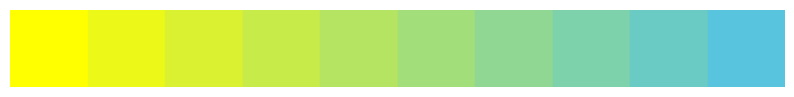

In [10]:
fig, ax = plt.subplots(figsize=(10, 2))

for i, color in enumerate(colors):
    ax.add_patch(
        Rectangle((i, 0), 1, 1, color=color.to_hex())
    )

ax.set_xlim(0, len(colors))
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.axis('off')

plt.show()

In [12]:
# each color is mapped to a number t belongs to [0,1)
color_maps = {
    '#FFFF00': 0,
    '#ECF818': 1/10,
    '#D9F131': 2/10,
    '#C7EB49': 3/10,
    '#B4E462': 4/10,
    '#A2DE7A': 5/10,
    '#8FD793': 6/10,
    '#7DD1AB': 7/10,
    '#6ACAC4': 8/10,
    '#58C4DD': 9/10
}

In [17]:
value_to_color = {
    round(v, 1): k
    for k, v in color_maps.items()
}

In [19]:
# defining a binary composition on the mapped numbers
# C(a) * C(b) = C(a+b) if (a+b) >=1 then we subtract 1 from it 
compositons = []
for value_x in color_maps.values():
    batch = []
    for value_y in color_maps.values():
        compose = value_x + value_y
        if compose >=1 :
            compose = compose - 1
        else: 
            compose = compose
        compose = round(compose, 1)
        batch.append(value_to_color[compose])
    compositons.append(batch)

for compositon in compositons:
    print(compositon)

['#FFFF00', '#ECF818', '#D9F131', '#C7EB49', '#B4E462', '#A2DE7A', '#8FD793', '#7DD1AB', '#6ACAC4', '#58C4DD']
['#ECF818', '#D9F131', '#C7EB49', '#B4E462', '#A2DE7A', '#8FD793', '#7DD1AB', '#6ACAC4', '#58C4DD', '#FFFF00']
['#D9F131', '#C7EB49', '#B4E462', '#A2DE7A', '#8FD793', '#7DD1AB', '#6ACAC4', '#58C4DD', '#FFFF00', '#ECF818']
['#C7EB49', '#B4E462', '#A2DE7A', '#8FD793', '#7DD1AB', '#6ACAC4', '#58C4DD', '#FFFF00', '#ECF818', '#D9F131']
['#B4E462', '#A2DE7A', '#8FD793', '#7DD1AB', '#6ACAC4', '#58C4DD', '#FFFF00', '#ECF818', '#D9F131', '#C7EB49']
['#A2DE7A', '#8FD793', '#7DD1AB', '#6ACAC4', '#58C4DD', '#FFFF00', '#ECF818', '#D9F131', '#C7EB49', '#B4E462']
['#8FD793', '#7DD1AB', '#6ACAC4', '#58C4DD', '#FFFF00', '#ECF818', '#D9F131', '#C7EB49', '#B4E462', '#A2DE7A']
['#7DD1AB', '#6ACAC4', '#58C4DD', '#FFFF00', '#ECF818', '#D9F131', '#C7EB49', '#B4E462', '#A2DE7A', '#8FD793']
['#6ACAC4', '#58C4DD', '#FFFF00', '#ECF818', '#D9F131', '#C7EB49', '#B4E462', '#A2DE7A', '#8FD793', '#7DD1AB']
[

In [20]:
colors = list(color_maps.keys())
compositions = []
for i in range(10):
    row = []
    for j in range(10):
        row.append(colors[(i + j) % 10])
    compositions.append(row)

[06/11/26 15:29:50] INFO     Substituting symbol Z from STIXGeneral                                ]8;id=566627;file://C:\Users\KUSHANKUR\AppData\Roaming\Python\Python313\site-packages\matplotlib\_mathtext.py\_mathtext.py]8;;\:]8;id=639424;file://C:\Users\KUSHANKUR\AppData\Roaming\Python\Python313\site-packages\matplotlib\_mathtext.py#648\648]8;;\

                    INFO     Substituting symbol Z from STIXGeneral                                ]8;id=216880;file://C:\Users\KUSHANKUR\AppData\Roaming\Python\Python313\site-packages\matplotlib\_mathtext.py\_mathtext.py]8;;\:]8;id=3879;file://C:\Users\KUSHANKUR\AppData\Roaming\Python\Python313\site-packages\matplotlib\_mathtext.py#648\648]8;;\

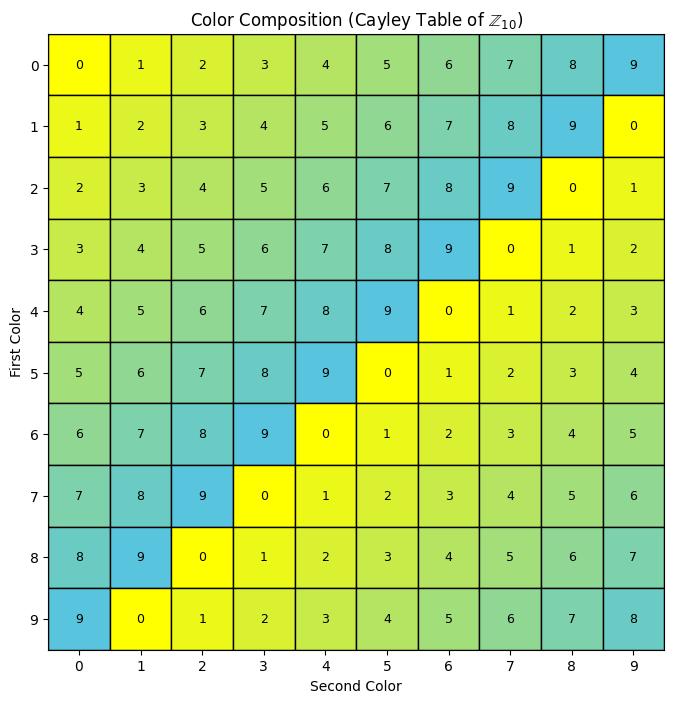

In [21]:
n = len(colors)

fig, ax = plt.subplots(figsize=(8, 8))

for i in range(n):
    for j in range(n):
        color = compositions[i][j]

        ax.add_patch(
            Rectangle((j, n-1-i), 1, 1,
                      facecolor=color,
                      edgecolor='black')
        )
        ax.text(
            j + 0.5,
            n - 1 - i + 0.5,
            str((i + j) % n),
            ha='center',
            va='center',
            fontsize=9
        )
        
ax.set_xticks([i + 0.5 for i in range(n)])
ax.set_xticklabels(range(n))

ax.set_yticks([i + 0.5 for i in range(n)])
ax.set_yticklabels(range(n-1, -1, -1))

ax.set_xlabel("Second Color")
ax.set_ylabel("First Color")
ax.set_title("Color Composition (Cayley Table of $\\mathbb{Z}_{10}$)")

ax.set_xlim(0, n)
ax.set_ylim(0, n)
ax.set_aspect('equal')

plt.show()

In [22]:
import plotly.graph_objects as go
import numpy as np

colors = list(color_maps.keys())
n = len(colors)

z = np.array([[(i + j) % n for j in range(n)] for i in range(n)])


composition_colors = [
    [colors[(i + j) % n] for j in range(n)]
    for i in range(n)
]

fig = go.Figure()

for i in range(n):
    for j in range(n):
        fig.add_shape(
            type="rect",
            x0=j,
            x1=j+1,
            y0=n-i-1,
            y1=n-i,
            fillcolor=composition_colors[i][j],
            line=dict(color="black", width=1)
        )

        fig.add_annotation(
            x=j+0.5,
            y=n-i-0.5,
            text=str(z[i, j]),
            showarrow=False,
            font=dict(size=12)
        )

fig.update_layout(
    title="Color Composition (Cayley Table of Z₁₀)",
    width=700,
    height=700,
    xaxis=dict(
        tickmode='array',
        tickvals=[i+0.5 for i in range(n)],
        ticktext=list(range(n)),
        title="Second Color",
        range=[0, n],
        showgrid=False,
        zeroline=False
    ),
    yaxis=dict(
        tickmode='array',
        tickvals=[i+0.5 for i in range(n)],
        ticktext=list(range(n-1, -1, -1)),
        title="First Color",
        range=[0, n],
        scaleanchor="x",
        showgrid=False,
        zeroline=False
    ),
    plot_bgcolor='white'
)

fig.show()